# Xsuite version of m4 line

Reads in m4.madx

In [11]:
from cpymad.madx import Madx
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

In [12]:
mad = Madx(stdout=False)  # Otherwise it will dump all the output to the screen

In [13]:
# This call will execute the entire file, including any resulting plots
mad.call(file="m4.madx")

In [14]:
line=xt.Line.from_madx_sequence(mad.sequence['M4line'])

Converting sequence "m4line": 100%|██████████| 360/360 [00:00<00:00, 906.27it/s]


In [15]:
#line.build_tracker()

In [16]:
# It does not remember the definition at the beginning of the MadX file, so you 
# need ti explicitly import it.
line.particle_ref = xp.Particles(
    p0c=mad.sequence['M4line'].beam.pc * 1e9,
    q0=1,     # charge
    mass0=xp.PROTON_MASS_EV
)

# I'm supposed to be able to access beta0 definitions from the file, but I couldn't, so I copied them here.
tw = line.twiss(betx=12.22350,
                 alfx=1.88239, 
                 bety=5.61627, 
                 alfy=-0.61825,
                 dx=0.02765,dpx=0.00346,
                 dy=-0.12410,
                 dpy=-0.07144)


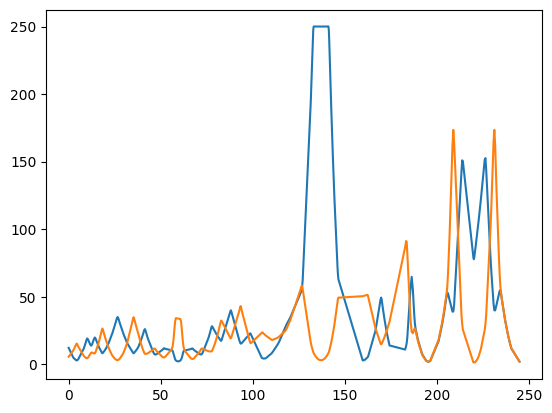

In [17]:
# Print a few optics parameters
plt.plot(tw.s,tw.betx)
plt.plot(tw.s,tw.bety)
plt.show()